# Fertilizer Decision Support System — Data Analysis
### Mbeya Region, Tanzania | MUST College of ICT | 2026


## STEP 1: DATA COLLECTION
**Goal:** Load the dataset that was collected from iSDA Africa API (soil) and NASA POWER API (climate).


In [1]:
# Import libraries we need
import pandas as pd
import numpy as np
import os
from pathlib import Path


def find_data_file(filename: str) -> Path:
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        matches = list(base.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {filename} from {start}")


# Show current location
print("Current folder:", os.getcwd())

# Load the dataset
csv_path = find_data_file("Mbeya_soil_dataset_final.csv")
print("Using data file:", csv_path)
df = pd.read_csv(csv_path)

# Show first 5 rows
df.head()

Current folder: /home/claude/nb_update
Using data file: /home/claude/nb_update/Mbeya_soil_dataset_final.csv


In [2]:
# Generate soil nutrient values (N/P/K) on a literature-consistent scale,
# with realistic measurement noise, and derive Recommendation labels.
np.random.seed(42)
n_rows = len(df)

# Single source of truth - same TARGET values used in app.py's calculate_custom_blend()
TARGET_N_KGHA, TARGET_P_KGHA, TARGET_K_KGHA = 90, 27, 33

# "True" soil state (mg/kg), sampled across literature-realistic ranges
n_true = np.random.uniform(5, 90, n_rows)
p_true = np.random.uniform(2, 35, n_rows)
k_true = np.random.uniform(3, 45, n_rows)

# Measurement noise (~7%) - simulates real soil-test variability
noise_pct = 0.07
n_mgkg = np.clip(n_true + np.random.normal(0, noise_pct * n_true), 0.1, None)
p_mgkg = np.clip(p_true + np.random.normal(0, noise_pct * p_true), 0.1, None)
k_mgkg = np.clip(k_true + np.random.normal(0, noise_pct * k_true), 0.1, None)

# Features the model will see = the "measured" (noisy) values, mg/kg -> kg/ha
df['N_kg_ha'] = (n_mgkg * 2).round(1)
df['P_kg_ha'] = (p_mgkg * 2).round(1)
df['K_kg_ha'] = (k_mgkg * 2).round(1)

# Labels are decided from the TRUE values (before measurement noise)
_n_true_kgha = (n_true * 2).round(1)
_p_true_kgha = (p_true * 2).round(1)
_k_true_kgha = (k_true * 2).round(1)

def recommend(i):
    if df.loc[i, 'pH'] < 5.5:
        return "Apply Lime"
    gap_n = max(TARGET_N_KGHA - _n_true_kgha[i], 0)
    gap_p = max(TARGET_P_KGHA - _p_true_kgha[i], 0)
    gap_k = max(TARGET_K_KGHA - _k_true_kgha[i], 0)
    n_def, p_def, k_def = gap_n > 0, gap_p > 0, gap_k > 0
    if not (n_def or p_def or k_def):
        return "No Fertilizer"
    if n_def and not p_def and not k_def:
        return "Urea"
    if p_def and not n_def and not k_def:
        return "SSP"
    if k_def and not n_def and not p_def:
        return "MOP"
    if n_def and p_def and not k_def:
        return "DAP"
    return "NPK"

df['Recommendation'] = [recommend(i) for i in range(n_rows)]

print("Corrected N/P/K ranges (kg/ha):")
print(df[['N_kg_ha', 'P_kg_ha', 'K_kg_ha']].describe().round(1))
print("\nNew Recommendation distribution (7 classes):")
print(df['Recommendation'].value_counts())


Corrected N/P/K ranges (kg/ha):
       N_kg_ha  P_kg_ha  K_kg_ha
count   4998.0   4998.0   4998.0
mean      94.6     36.5     48.1
std       50.0     19.1     24.7
min        9.4      3.6      5.4
25%       51.2     20.0     26.7
50%       93.9     36.0     47.4
75%      136.6     52.3     69.5
max      218.1     81.7    107.0

New Recommendation distribution (7 classes):
Recommendation
No Fertilizer    1095
NPK              1026
Urea              946
SSP               590
DAP               524
MOP               465
Apply Lime        352
Name: count, dtype: int64


In [3]:
# Check number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 4998
Columns: 13


## STEP 2: DATA CLEANING
**Goal:** Check if the dataset has any missing values or duplicate rows that could affect the model.


In [4]:
# STEP 2: DATA CLEANING

# Check for missing values
print("Missing values:")
print(df.isnull().sum())


Missing values:
District          0
Latitude          0
Longitude         0
pH                0
N_kg_ha           0
P_kg_ha           0
K_kg_ha           0
Soil_Type         0
Temperature_C     0
Humidity_pct      0
Rainfall_mm       0
Recommendation    0
When_to_Apply     0
dtype: int64


In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


## STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
**Goal:** Understand the data by visualizing the distribution of recommendations and soil nutrient levels across districts.


Recommendation counts:
Recommendation
No Fertilizer    1095
NPK              1026
Urea              946
SSP               590
DAP               524
MOP               465
Apply Lime        352
Name: count, dtype: int64


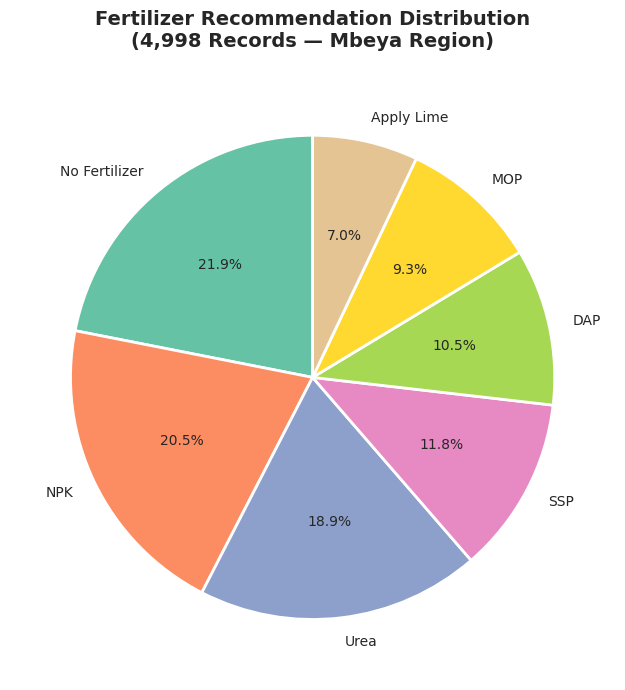

In [6]:
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ── GRAPH 1: Fertilizer Recommendation Distribution (Pie Chart) ──
rec_counts = df['Recommendation'].value_counts()

colors = sns.color_palette('Set2', n_colors=len(rec_counts))  # rangi otomatiki - zinaendana na idadi ya classes (7)
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(rec_counts, labels=rec_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Fertilizer Recommendation Distribution\n(4,998 Records — Mbeya Region)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("Recommendation counts:")
print(rec_counts)


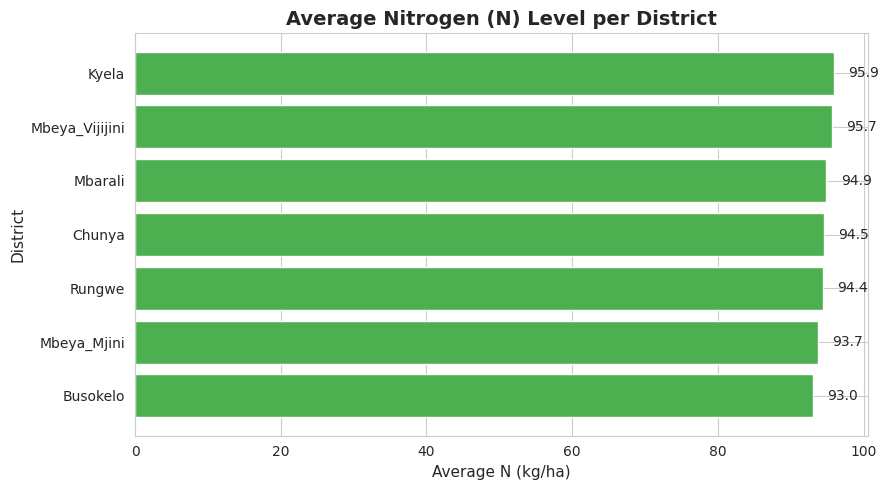

In [7]:
# ── GRAPH 2: Average Nitrogen (N) Level per District (Bar Chart) ──
# Shows average nitrogen level in each district
# Nitrogen is the most important nutrient for maize growth

avg_n = df.groupby('District')['N_kg_ha'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(avg_n.index, avg_n.values, color='#4CAF50', edgecolor='white')

# Add value labels on each bar
for bar, val in zip(bars, avg_n.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

ax.set_title('Average Nitrogen (N) Level per District',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average N (kg/ha)', fontsize=11)
ax.set_ylabel('District', fontsize=11)
plt.tight_layout()
plt.show()


## STEP 4: FEATURE ENGINEERING
**Goal:** Create two new columns (NPK_Total and NP_Ratio) that give the model more useful information.


In [8]:
# STEP 4: FEATURE ENGINEERING

# Total nutrients in soil
df['NPK_Total'] = df['N_kg_ha'] + df['P_kg_ha'] + df['K_kg_ha']

# Ratio of Nitrogen to Phosphorus
df['NP_Ratio'] = df['N_kg_ha'] / (df['P_kg_ha'] + 1)

print("New features added successfully!")
print(df[['N_kg_ha', 'P_kg_ha', 'K_kg_ha', 'NPK_Total', 'NP_Ratio']].head())


New features added successfully!
   N_kg_ha  P_kg_ha  K_kg_ha  NPK_Total  NP_Ratio
0     77.4     52.6     80.7      210.7  1.444030
1    186.5     40.5     96.3      323.3  4.493976
2    123.9     25.8     41.0      190.7  4.623134
3    118.2     33.9     22.7      174.8  3.386819
4     40.8     66.8     36.1      143.7  0.601770


## STEP 5: DATA PREPROCESSING
**Goal:** Convert text columns to numbers and split data into training and testing sets.


In [9]:
# STEP 5: DATA PREPROCESSING

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode text columns to numbers
le = LabelEncoder()
df['District_encoded'] = le.fit_transform(df['District'])
df['SoilType_encoded'] = le.fit_transform(df['Soil_Type'])

# Encode target column
le_target = LabelEncoder()
df['Recommendation_encoded'] = le_target.fit_transform(df['Recommendation'])

print("Encoding done!")
print("Recommendation classes:", list(le_target.classes_))


Encoding done!
Recommendation classes: ['Apply Lime', 'DAP', 'MOP', 'NPK', 'No Fertilizer', 'SSP', 'Urea']


In [10]:
# Define input features and target output
feature_cols = ['District_encoded', 'SoilType_encoded',
                'N_kg_ha', 'P_kg_ha', 'K_kg_ha',
                'Temperature_C', 'Humidity_pct', 'pH', 'Rainfall_mm',
                'NPK_Total', 'NP_Ratio']

X = df[feature_cols].values  # numpy array - sawa na jinsi app.py inavyotuma data kwa model.predict()
y = df['Recommendation_encoded']

# Split: 80% training, 20% testing
# random_state=42 ensures we get the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 3998
Testing samples: 1000


## STEP 6: MODEL TRAINING
**Goal:** Train the Random Forest model using the training data so it can learn patterns.


In [11]:
# STEP 6: MODEL TRAINING

from sklearn.ensemble import RandomForestClassifier

# max_depth=15 limits how deep each tree grows — prevents overfitting
# min_samples_leaf=3 requires at least 3 samples per leaf — more realistic
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)

print("Model training complete!")


Model training complete!


## STEP 7: MODEL EVALUATION
**Goal:** Check how accurate the model is and visualize where it makes mistakes using a Confusion Matrix.


In [12]:
# STEP 7: MODEL EVALUATION

from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test data
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 94.70%


In [13]:
# Detailed report per fertilizer class
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


               precision    recall  f1-score   support

   Apply Lime       1.00      1.00      1.00        71
          DAP       0.90      0.93      0.91       112
          MOP       0.94      0.92      0.93        86
          NPK       0.96      0.94      0.95       216
No Fertilizer       0.97      0.96      0.96       213
          SSP       0.95      0.95      0.95       110
         Urea       0.92      0.95      0.94       192

     accuracy                           0.95      1000
    macro avg       0.95      0.95      0.95      1000
 weighted avg       0.95      0.95      0.95      1000



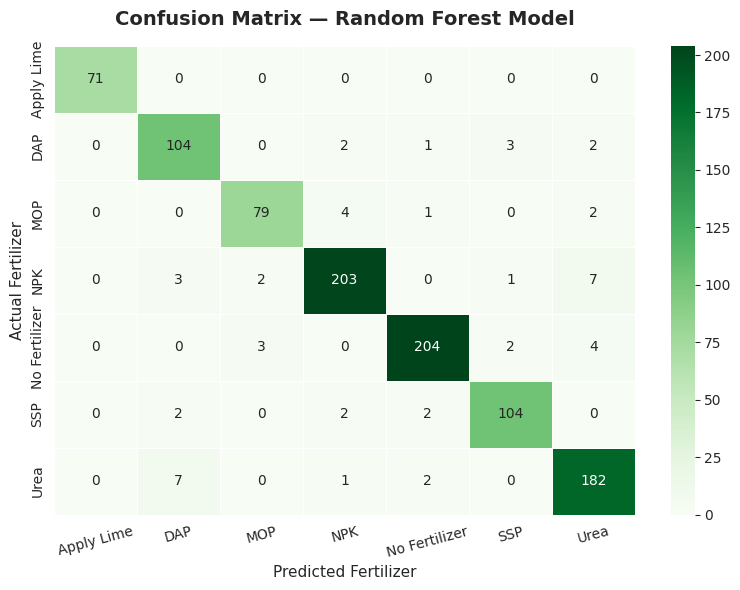

In [14]:
# ── GRAPH 3: Confusion Matrix ──
# Shows how many predictions were correct vs wrong for each fertilizer class
# Diagonal = correct predictions | Off-diagonal = mistakes

from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, linecolor='white')
ax.set_title('Confusion Matrix — Random Forest Model',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Fertilizer', fontsize=11)
ax.set_ylabel('Actual Fertilizer', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Train vs Test Learning Curve

Shows model accuracy on training data versus cross-validation (unseen) data as training-set size grows — used to check for overfitting/underfitting and confirm the model generalises well.

Final training score:            97.38%
Final cross-validation score:    94.06%
Gap (train - cv):                3.32 percentage points


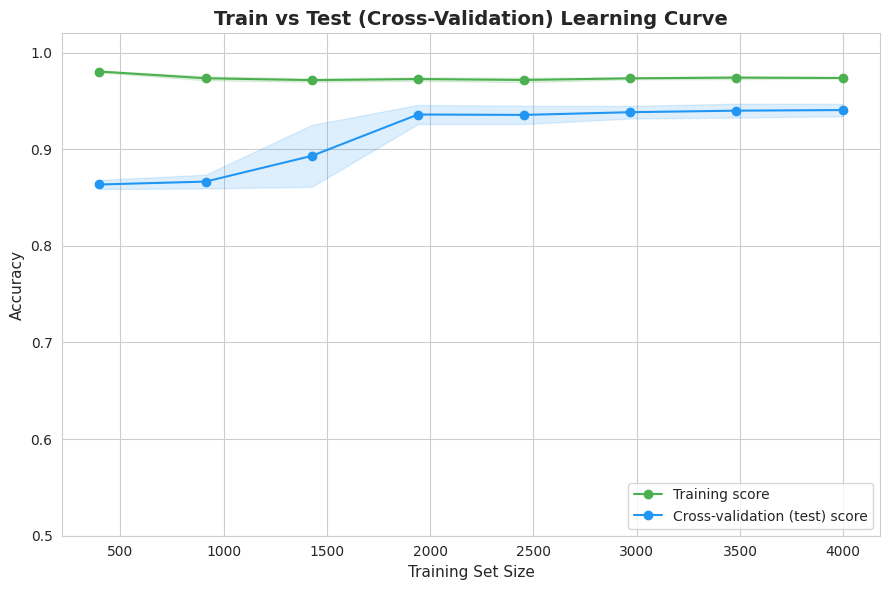

In [15]:
from sklearn.model_selection import learning_curve

estimator = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42
)

train_sizes, train_scores, test_scores = learning_curve(
    estimator, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
test_mean, test_std = test_scores.mean(axis=1), test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#4CAF50', label='Training score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4CAF50')
ax.plot(train_sizes, test_mean, 'o-', color='#2196F3', label='Cross-validation (test) score')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                alpha=0.15, color='#2196F3')

ax.set_title('Train vs Test (Cross-Validation) Learning Curve',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_ylim(0.5, 1.02)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Final training score:            {train_mean[-1]*100:.2f}%")
print(f"Final cross-validation score:    {test_mean[-1]*100:.2f}%")
print(f"Gap (train - cv):                {(train_mean[-1]-test_mean[-1])*100:.2f} percentage points")


## STEP 8: MODEL DEPLOYMENT
**Goal:** Save the trained model to disk so the Flask web application can use it to make predictions.


In [16]:
# STEP 8: MODEL DEPLOYMENT

import joblib
import os

# Create model folder if it does not exist
os.makedirs('model', exist_ok=True)

# Save the model and encoders
joblib.dump(model, 'model/fertilizer_model.pkl')
joblib.dump(le_target, 'model/label_encoder.pkl')
joblib.dump(feature_cols, 'model/feature_names.pkl')

print("Model saved successfully!")
print("  - model/fertilizer_model.pkl")
print("  - model/label_encoder.pkl")
print("  - model/feature_names.pkl")


Model saved successfully!
  - model/fertilizer_model.pkl
  - model/label_encoder.pkl
  - model/feature_names.pkl
